<a href="https://colab.research.google.com/github/danyalahmed12112/AI-Tasks/blob/main/StockPrice_Predicion.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install yfinance

In [ ]:
import pandas as pd
import yfinance as yf
import matplotlib.pyplot as plt
import numpy as np
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error
from sklearn.model_selection import train_test_split

In [ ]:
#selecting the stock and Load Data
ticker ='TSLA'
 # Fetching the data upto current date
data= yf.download(ticker, start='2020-01-01')

/tmp/ipykernel_2999/1119103553.py:4: FutureWarning: YF.download() has changed argument auto_adjust default to True
  data= yf.download(ticker, start='2020-01-01')
[*********************100%***********************]  1 of 1 completed


In [ ]:
# Make sure data should be clean
data= data.dropna()

In [ ]:
data.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 1587 entries, 2020-01-02 to 2026-04-27
Data columns (total 5 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   (Close, TSLA)   1587 non-null   float64
 1   (High, TSLA)    1587 non-null   float64
 2   (Low, TSLA)     1587 non-null   float64
 3   (Open, TSLA)    1587 non-null   float64
 4   (Volume, TSLA)  1587 non-null   int64  
dtypes: float64(4), int64(1)
memory usage: 74.4 KB


In [ ]:
data.columns

MultiIndex([( 'Close', 'TSLA'),
            (  'High', 'TSLA'),
            (   'Low', 'TSLA'),
            (  'Open', 'TSLA'),
            ('Volume', 'TSLA')],
           names=['Price', 'Ticker'])

In [ ]:
data.describe()

Price,Close,High,Low,Open,Volume
Ticker,TSLA,TSLA,TSLA,TSLA,TSLA
count,1587.000000,1587.000000,1587.000000,1587.000000,1.587000e+03
mean,245.457032,250.886964,239.831734,245.540952,1.180714e+08
std,101.646025,103.627262,99.749306,101.848095,7.610777e+07
min,24.081333,26.990667,23.367332,24.980000,2.940180e+07
25%,185.834999,189.255005,182.000000,185.389999,7.218895e+07
50%,238.886673,244.666672,233.960007,239.250000,9.720990e+07
75%,308.606659,313.944992,300.811661,307.890015,1.342616e+08
max,489.880005,498.829987,485.329987,489.880005,9.140820e+08


In [ ]:
# Data preparation
#want to predict the Close Price of Next day
#So we need to shift to the close column up by 1 to create the target variable

data['Target']= data['Close'].shift(-1)

In [ ]:
print(data)

Price            Close        High         Low        Open     Volume  \
Ticker            TSLA        TSLA        TSLA        TSLA       TSLA   
Date                                                                    
2020-01-02   28.684000   28.713333   28.114000   28.299999  142981500   
2020-01-03   29.534000   30.266666   29.128000   29.366667  266677500   
2020-01-06   30.102667   30.104000   29.333332   29.364668  151995000   
2020-01-07   31.270666   31.441999   30.224001   30.760000  268231500   
2020-01-08   32.809334   33.232666   31.215334   31.580000  467164500   
...                ...         ...         ...         ...        ...   
2026-04-21  386.420013  393.950012  385.220001  393.000000   50530600   
2026-04-22  387.510010  393.010010  385.299988  387.570007   62362800   
2026-04-23  373.720001  386.000000  368.390015  375.279999   93969500   
2026-04-24  376.299988  382.760010  370.730011  373.500000   62893300   
2026-04-27  378.670013  380.779999  364.019989  372

In [ ]:
display(data)

Price,Close,High,Low,Open,Volume,Target
Ticker,TSLA,TSLA,TSLA,TSLA,TSLA,
Date,,,,,,
2020-01-02,28.684000,28.713333,28.114000,28.299999,142981500,29.534000
2020-01-03,29.534000,30.266666,29.128000,29.366667,266677500,30.102667
2020-01-06,30.102667,30.104000,29.333332,29.364668,151995000,31.270666
2020-01-07,31.270666,31.441999,30.224001,30.760000,268231500,32.809334
2020-01-08,32.809334,33.232666,31.215334,31.580000,467164500,32.089333
...,...,...,...,...,...,...
2026-04-21,386.420013,393.950012,385.220001,393.000000,50530600,387.510010
2026-04-22,387.510010,393.010010,385.299988,387.570007,62362800,373.720001


In [ ]:
df=data.dropna()

In [ ]:
#Feature selection
features= ['Open','High','Low','Volume']
X=df[features]
y=df['Target']


In [ ]:
#3 split train test
split_index= int(len(df)* 0.8)
X_train, X_test= X.iloc[:split_index], X.iloc[split_index:]
y_train, y_test= y.iloc[:split_index], y.iloc[split_index:]

In [ ]:
#Model training
model= RandomForestRegressor(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

RandomForestRegressor(random_state=42)

In [ ]:
#prediction and Evaluation

prd= model.predict(X_test)
mae= mean_squared_error(y_test, prd)
print(f"Mean Absolute Error: {mae:.2f}")

Mean Absolute Error: 247.54


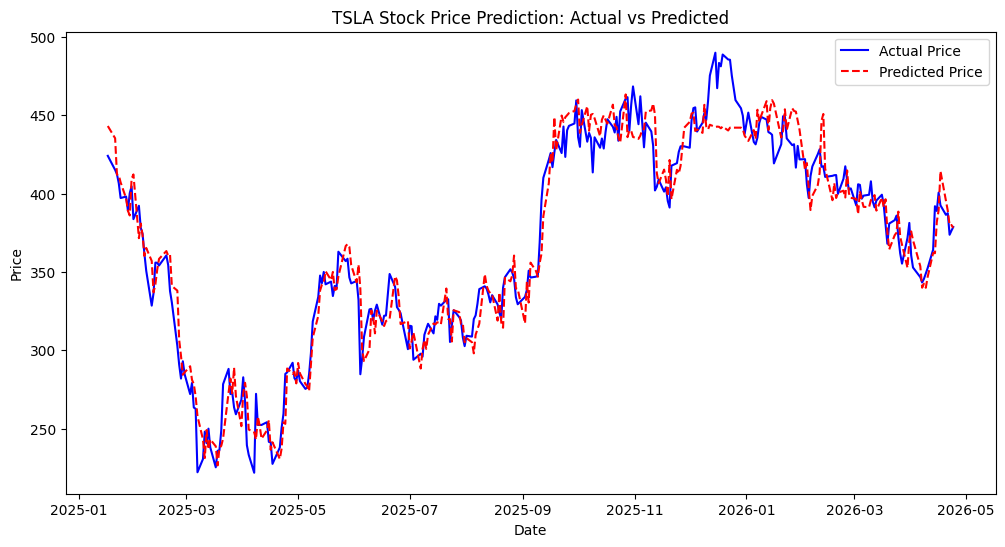

In [ ]:
# Plotting actual vs predicted values
plt.figure(figsize=(12,6))
plt.plot(y_test.index, y_test.values, label='Actual Price', color='blue')
plt.plot(y_test.index, prd, label='Predicted Price', color='red', linestyle='dashed')
plt.title(f'{ticker} Stock Price Prediction: Actual vs Predicted')
plt.xlabel('Date')
plt.ylabel('Price')
plt.legend()
plt.show()